# Panels 4I and 4J

Split from `ahmm_final_figures.ipynb`. Covers PV covariance lag curves and real-vs-shuffle within-session PV covariance analyses.


In [1]:
import pickle
from datetime import datetime

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from ahmm_eval import (
    build_cat_ids_from_obs_labels,
    build_conditioned_obs_heatmap,
    build_similarity_matrix,
    build_within_session_pv_cov_df_best_models,
    collect_left_tuning_all_sessions_from_df,
    collect_pv_lag_curves_for_best_models,
    compute_state_tuning_all_obs,
    load_best_pde_model_for_session,
    load_within_session_model_for_session,
    model_action_distribution_all_sessions,
    obs_heatmap_corr_for_session_and_model,
    prepare_obs_heatmap_crosscorr_2x2,
    sample_ahmm,
    save_pv_df_to_mat,
    select_left_bar_tuning,
    prep_dfv_for_heatmap,
        repair_model_paths,
    resolve_data_path,
)
from ahmm_plotting import (
    build_obs_raster_sorted,
    make_obs_colors,
    parula,
    plot_conditioned_obs_heatmap,
    plot_confusion_heatmap,
    plot_heatmap_and_pc_loadings,
    plot_metric_heatmap,
    plot_model_action_heatmap,
    plot_obj1_tuning_heatmap,
    plot_obs_raster_sorted,
    plot_pv_df_violin_sanity,
    plot_pv_lag_mean_sem,
    plot_tuning_heatmap,
    show_pv_representation_ahmm_dataset,
)
from ahmm_utils import (
    SingleTrackConfig,
    SingleTrackGenerator,
    Vocab,
    build_vocab,
    load_ahmm,
    make_session_lookup,
    records_to_dataset,
    train_test_split_random,
)




In [2]:
sessions_combined = pd.read_pickle(resolve_data_path('sessions_combined.pkl', data_roots=('data','demo_data','.')))



In [3]:
heights_in_data = sorted({
    int(h) for sess in sessions_combined for (h, _, _) in sess["records"]
} | {
    int(h) for sess in sessions_combined for (_, h, _) in sess["records"]
})
heights = heights_in_data  # or overwrite with your canonical list if you prefer

vocab: Vocab = build_vocab(heights, height_encoding='split')

# Your deterministic task config (you can change these to experiment)
cfg = SingleTrackConfig(
    tower_heights=heights,
    height_encoding='split',
    p_gap=1.0,
    p_reward_given_correct=1.0,
    p_reward_given_incorrect=0.0
)
gen = SingleTrackGenerator(vocab, cfg)

action_labels = [vocab.id_to_action[i] for i in range(len(vocab.id_to_action))]
obs_labels    = [k for k,_ in sorted(vocab.obs_to_id.items(), key=lambda kv: kv[1])]
obs_colors    = make_obs_colors(obs_labels)
sess_by_key = make_session_lookup(sessions_combined)




In [4]:
dfv_rand_25 = repair_model_paths(pd.read_pickle(resolve_data_path("dfv_rand_25.pkl", data_roots=("data","demo_data","."))))



In [5]:
df_25_rand = repair_model_paths(pd.read_pickle(resolve_data_path("df_25_rand.pkl", data_roots=("data","demo_data","."))))



In [6]:
cg_df_rand_25 = repair_model_paths(pd.read_pickle(resolve_data_path("rand_train_val_cg_rank1_pde_behavior_cross_compare_results_25_states.pkl", data_roots=("data","demo_data","."))))



### Figure 4I

In [7]:
lag_df = collect_pv_lag_curves_for_best_models(
    sessions_combined,
    gen,
    df_models=df_25_rand,
    matrix_metric="corr"
)
all_curves = lag_df["lag_mean"].tolist()



100%|██████████| 79/79 [00:00<00:00, 137.22it/s]


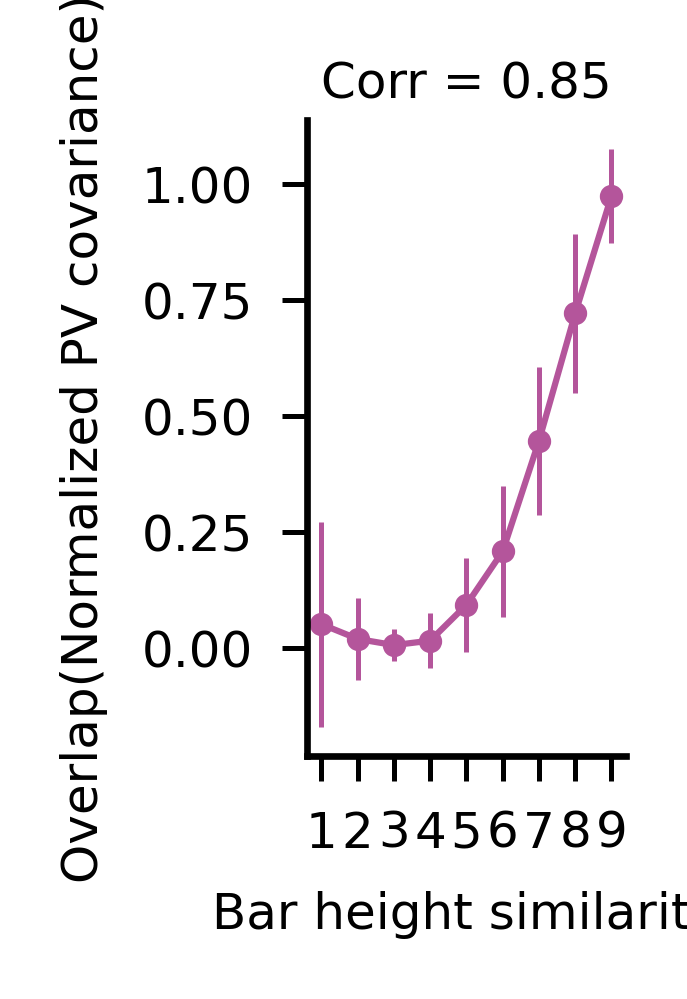

In [8]:
fig, ax = plot_pv_lag_mean_sem(
    all_curves,
    normalize="minmax",
    figsize_cm=(3.2, 4.5),
    dpi=600,
    fontsize=dict(
        corr=6,
        axis_label=6,
        tick=6,
    ),
    marker_size=1.8,
    line_width=0.75,
    err_line_width=0.6,
    tick_width=0.6,
    tick_length=3.0,
)




### Figure 4J

In [9]:
pv_df = build_within_session_pv_cov_df_best_models(
    sessions_combined,
    gen,
    vocab,
    df_models=df_25_rand,      # your df_25_rand
    n_shuffle=200,
    seed=0,
    matrix_metric="corr",
)



100%|██████████| 79/79 [00:17<00:00,  4.47it/s]


In [10]:
pv_df = pv_df.copy()
pv_df["cov_real"] = -pv_df["cov_real"]
pv_df["cov_shuffle"] = -pv_df["cov_shuffle"]




/Users/reaggy/Library/CloudStorage/OneDrive-NorthwesternUniversity/NUIN/Research/AHMM_open_repository/ahmm_plotting.py:1062: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=long, x="group", y="value", order=list(labels), inner="box", cut=0, linewidth=0.8, palette={labels[0]: violin_colors[0], labels[1]: violin_colors[1]}, ax=ax)
/Users/reaggy/Library/CloudStorage/OneDrive-NorthwesternUniversity/NUIN/Research/AHMM_open_repository/ahmm_plotting.py:1074: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right", fontsize=fontsize)


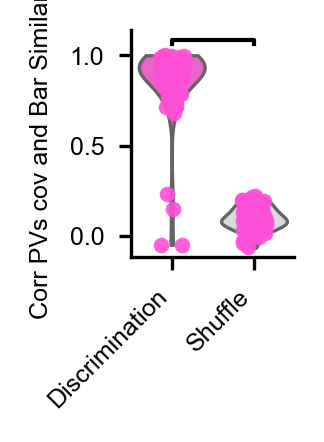

In [11]:
fig, ax = plot_pv_df_violin_sanity(
    pv_df,
    figsize_cm=(3, 4),
    # dpi=600,
    fontsize=6,
    ylabel="Corr PVs cov and Bar Similarity",
)

